# Analysis of Iris Species Data

## Analysis objective

The purpose of this data analysis report is to analyze whether there are significant differences in the mean sepal length, sepal width, petal length, and petal width between two iris species based on iris attribute data. This allows us to make inferences about the characteristic differences between different iris species.

## Introduction

The original dataset, `Iris.csv`, contains two iris species, with 50 samples for each species. Each sample includes several attributes, including sepal length, sepal width, petal length, and petal width.

The meanings of each column in `Iris.csv` are as follows:

- `Id`: The sample ID.
- `SepalLengthCm`: The length of the sepal, measured in centimeters.
- `SepalWidthCm`: The width of the sepal, measured in centimeters.
- `PetalLengthCm`: The length of the petal, measured in centimeters.
- `PetalWidthCm`: The width of the petal, measured in centimeters.
- `Species`: The iris species.

# Load data

Import the required libraries for data analysis and use Pandas’ `read_csv()` function to load the raw `Iris.csv` file into a DataFrame named `original_iris`.

In [1]:
import pandas as pd
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
original_iris = pd.read_csv("./Iris.csv")
original_iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
95,96,5.7,3.0,4.2,1.2,Iris-versicolor
96,97,5.7,2.9,4.2,1.3,Iris-versicolor
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
98,99,5.1,2.5,3.0,1.1,Iris-versicolor


## Data evaluation and cleaning

### Back up original data

In [3]:
cleaned_iris = original_iris.copy()

### Data tidiness

In [4]:
cleaned_iris.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
10,11,5.4,3.7,1.5,0.2,Iris-setosa
78,79,6.0,2.9,4.5,1.5,Iris-versicolor
16,17,5.4,3.9,1.3,0.4,Iris-setosa
42,43,4.4,3.2,1.3,0.2,Iris-setosa
67,68,5.8,2.7,4.1,1.0,Iris-versicolor
95,96,5.7,3.0,4.2,1.2,Iris-versicolor
35,36,5.0,3.2,1.2,0.2,Iris-setosa
14,15,5.8,4.0,1.2,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa


From a random sample of 10 rows, each column represents a variable, each row represents an observation, and each cell contains a single value. Therefore, the dataset is tidy.

### Data quality

In [5]:
cleaned_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 4.8 KB


The dataset contains 100 rows and 6 columns, with no missing values. The `Id` column should be stored as `str` because it represents sample identifiers, not values for calculation. The `Species` column should be stored as `category` because it contains a limited number of categorical labels.

In [6]:
cleaned_iris['Id'] = cleaned_iris['Id'].astype("str")
cleaned_iris['Species'] = cleaned_iris['Species'].astype("category")

In [7]:
cleaned_iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             100 non-null    str     
 1   SepalLengthCm  100 non-null    float64 
 2   SepalWidthCm   100 non-null    float64 
 3   PetalLengthCm  100 non-null    float64 
 4   PetalWidthCm   100 non-null    float64 
 5   Species        100 non-null    category
dtypes: category(1), float64(4), str(1)
memory usage: 4.1 KB


The updated `info()` output confirms that the `Id` column is now stored as `str`, while the `Species` column is stored as `category`.

#### Missing data

The dataset was checked for missing values before analysis. No missing data were found in any column, so no row removal was required.

#### Duplicated data

Based on the meaning and content of the variables, the `Id` column in `cleaned_iris` represents the unique identifier of each sample. Therefore, duplicate values should not exist in this column. The `Id` column was checked to confirm whether any duplicated sample IDs were present.

In [8]:
cleaned_iris["Id"].duplicated().sum()

np.int64(0)

No duplicated values were found in the `Id` column, indicating that each sample has a unique identifier.

#### Inconsistent data

Category values in the `Species` column were checked to identify any inconsistent or invalid entries before analysis.

In [9]:
cleaned_iris["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64

The result shows that the `Species` column contains two category values: `Iris-setosa` and `Iris-versicolor`. Each species has 50 samples. No inconsistent or invalid category names were found in this column, so no further cleaning was needed for the species labels.

#### Invalid or erroneous data

In [10]:
cleaned_iris.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,100.000000,100.000000,100.000000,100.000000
mean,5.471000,3.094000,2.862000,0.785000
std,0.641698,0.476057,1.448565,0.566288
min,4.300000,2.000000,1.000000,0.100000
25%,5.000000,2.800000,1.500000,0.200000
50%,5.400000,3.050000,2.450000,0.800000
75%,5.900000,3.400000,4.325000,1.300000
max,7.000000,4.400000,5.100000,1.800000


Based on the summary statistics, no obvious invalid or erroneous values were found in the numerical columns. The minimum and maximum values are within reasonable ranges, so these records were retained.

## Data analysis

The color palette was first adjusted to Set2 for a softer visualization style.

In [11]:
sns.set_palette("Set2")

### Comparison of numerical variables between species

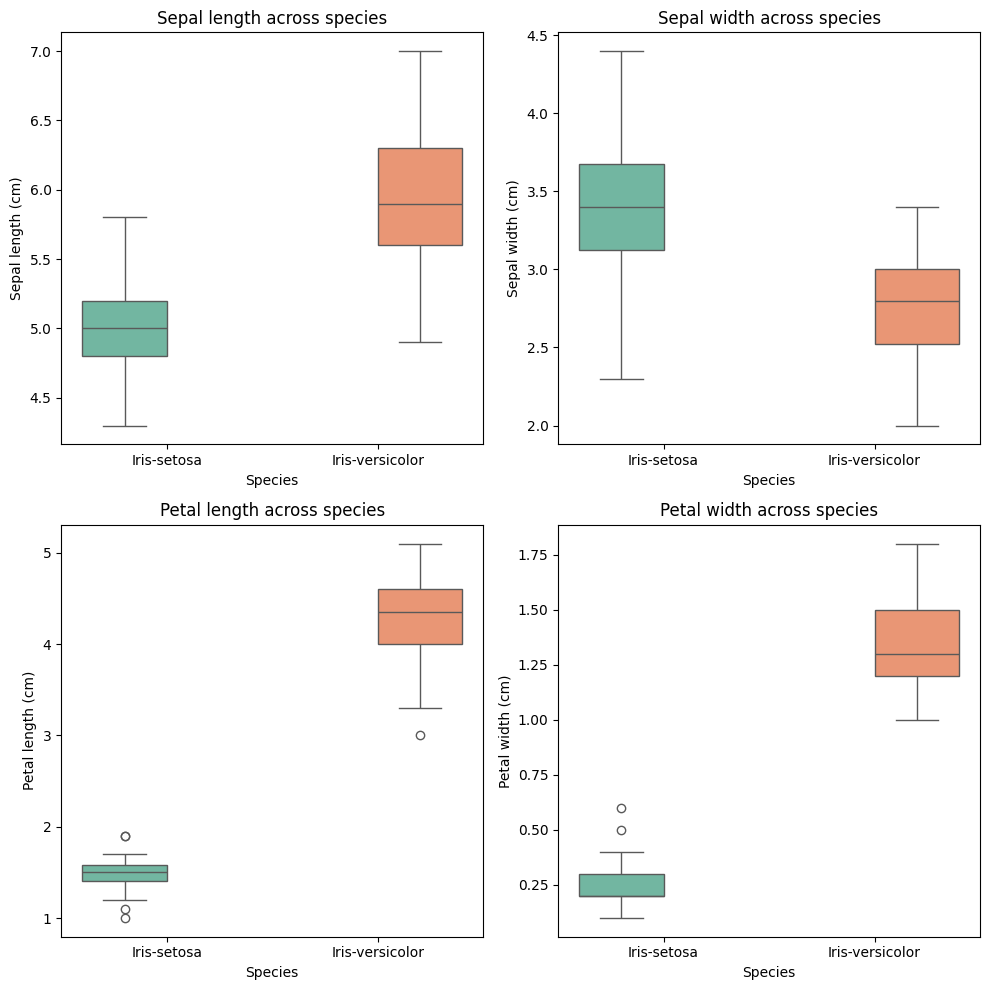

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

sns.boxplot(cleaned_iris, x="Species", y = "SepalLengthCm", hue="Species", ax=axes[0, 0])
sns.boxplot(cleaned_iris, x="Species", y = "SepalWidthCm", hue="Species", ax=axes[0, 1])
sns.boxplot(cleaned_iris, x="Species", y = "PetalLengthCm", hue="Species", ax=axes[1, 0])
sns.boxplot(cleaned_iris, x="Species", y = "PetalWidthCm", hue="Species", ax=axes[1, 1])

axes[0, 0].set_ylabel("Sepal length (cm)")
axes[0, 1].set_ylabel("Sepal width (cm)")
axes[1, 0].set_ylabel("Petal length (cm)")
axes[1, 1].set_ylabel("Petal width (cm)")

axes[0, 0].set_title("Sepal length across species")
axes[0, 1].set_title("Sepal width across species")
axes[1, 0].set_title("Petal length across species")
axes[1, 1].set_title("Petal width across species")

plt.tight_layout()
plt.show()

The boxplots compare four numerical features between Iris-setosa and Iris-versicolor. Overall, Iris-versicolor has larger sepal length, petal length, and petal width than Iris-setosa. Iris-setosa, however, tends to have a wider sepal width. The differences in petal length and petal width are especially clear, showing that petal-related features are more useful for distinguishing the two species. A few outliers can also be observed, particularly in the petal measurements.

### Overall variable relationships

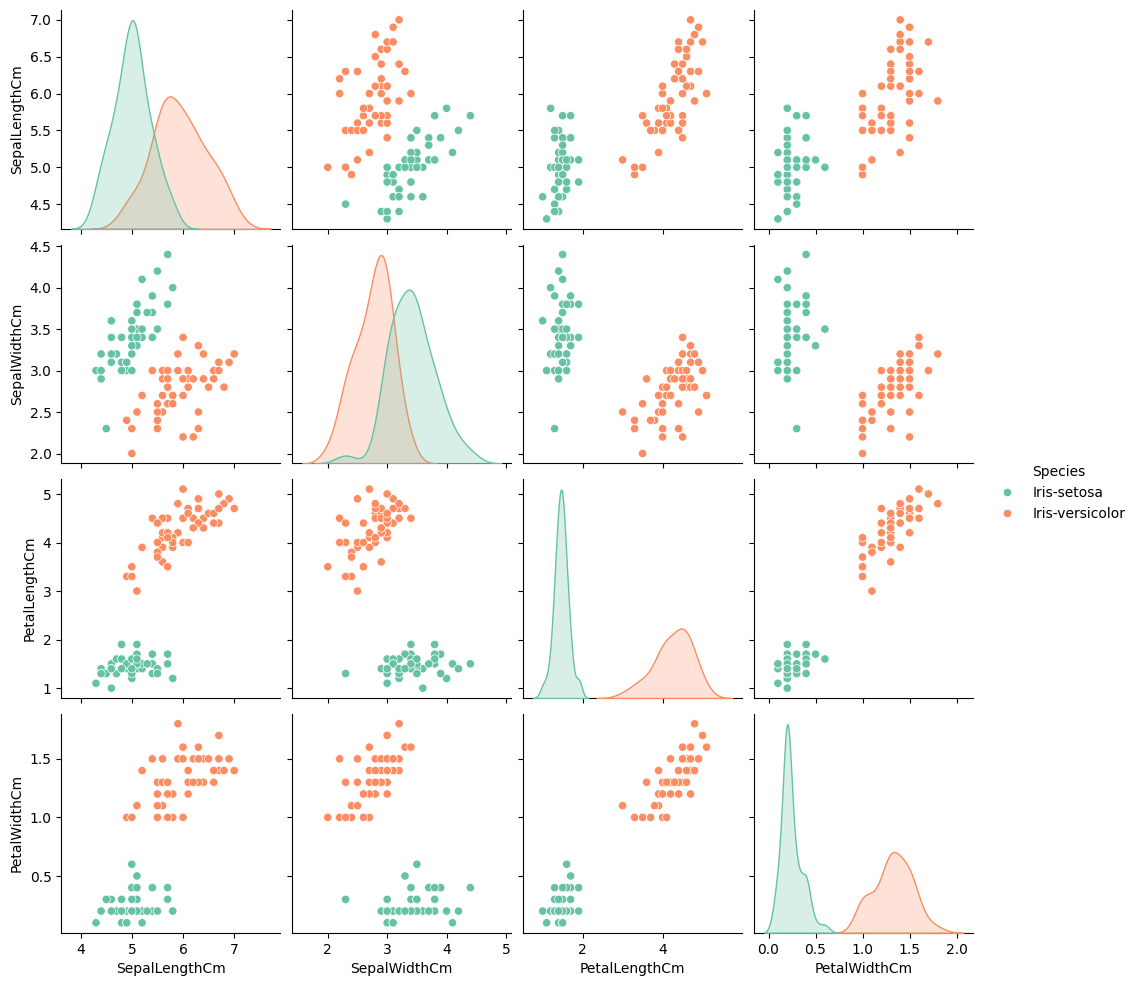

In [13]:
sns.pairplot(cleaned_iris, hue = 'Species')
plt.show()

The pairplot compares the relationships among sepal length, sepal width, petal length, and petal width for the two iris species. Iris-setosa and Iris-versicolor form two separate clusters in the scatter plots. The separation is clearest when petal length or petal width is used as one of the variables. The diagonal density plots also show that petal-related variables distinguish the two species more clearly than sepal-related variables.


### T-test analysis between species

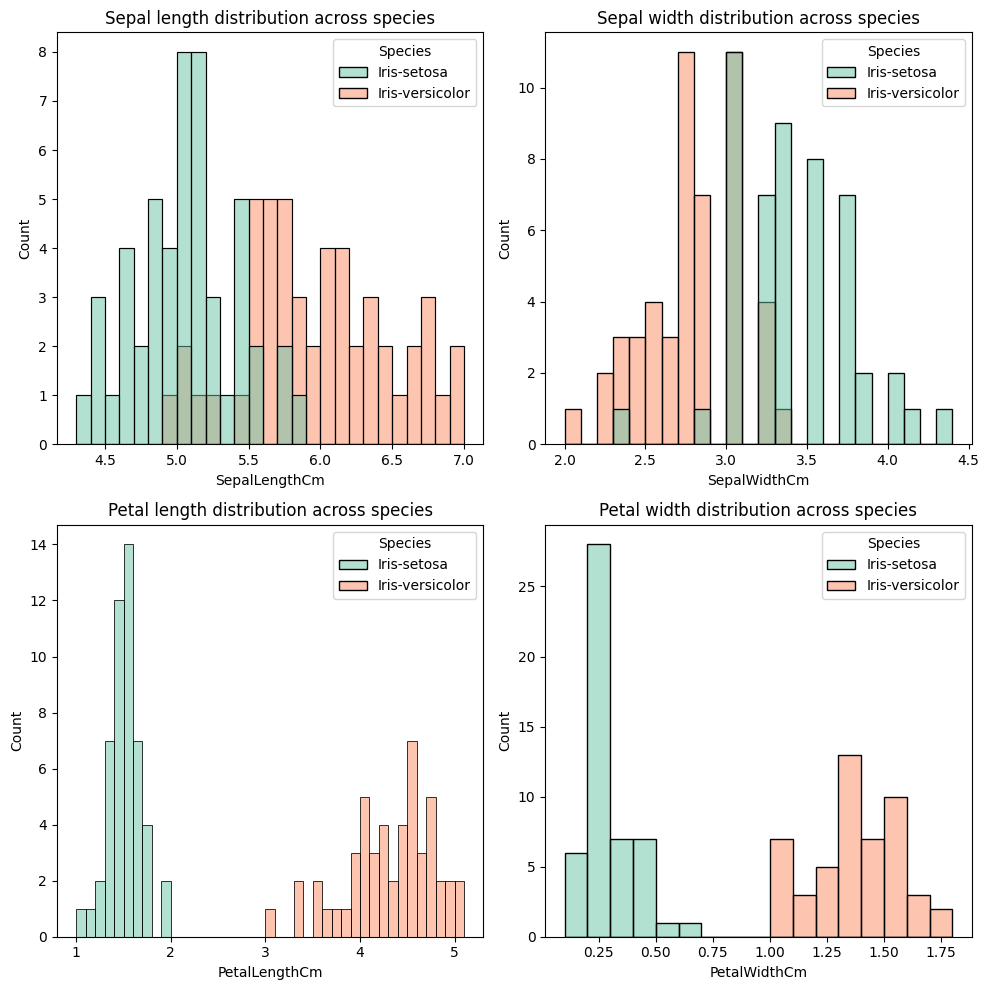

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

sns.histplot(cleaned_iris, x="SepalLengthCm", binwidth = 0.1, hue='Species', ax=axes[0, 0])
sns.histplot(cleaned_iris, x="SepalWidthCm", binwidth = 0.1, hue='Species', ax=axes[0, 1])
sns.histplot(cleaned_iris, x="PetalLengthCm", binwidth = 0.1, hue='Species', ax=axes[1, 0])
sns.histplot(cleaned_iris, x="PetalWidthCm", binwidth = 0.1, hue='Species', ax=axes[1, 1])


axes[0, 0].set_title("Sepal length distribution across species")
axes[0, 1].set_title("Sepal width distribution across species")
axes[1, 0].set_title("Petal length distribution across species")
axes[1, 1].set_title("Petal width distribution across species")

plt.tight_layout()
plt.show()

Independent two-sample t-tests are used to examine whether the mean values of numerical variables are significantly different between `Iris-setosa` and `Iris-versicolor`. Since the purpose is to test whether the two species differ, rather than whether one species has a greater or smaller mean value, two-tailed tests were used.

For each variable:

- $H_0$: There is no significant difference in the mean value between the two species.
- $H_1$: There is a significant difference in the mean value between the two species.

A significance level of 0.05 is used.

Select numerical variables for testing

In [15]:
numeric_columns = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

Split the dataset by species

In [16]:
setosa = cleaned_iris[cleaned_iris["Species"] == "Iris-setosa"]
versicolor = cleaned_iris[cleaned_iris["Species"] == "Iris-versicolor"]

Set significance level

In [17]:
alpha = 0.05

Analysis results

In [18]:
results = []

for col in numeric_columns:
    t_stat, p_value = ttest_ind(
        setosa[col],
        versicolor[col],
        alternative = 'two-sided'
    )
    
    results.append({
        "Variable": col,
        "t-statistic": t_stat,
        "p-value": p_value,
        "Significant": p_value < alpha
    })

test_results = pd.DataFrame(results)

test_results

,Variable,t-statistic,p-value,Significant
0,SepalLengthCm,-10.520986,8.985235e-18,True
1,SepalWidthCm,9.282773,4.362239e-15,True
2,PetalLengthCm,-39.468663,5.717464e-62,True
3,PetalWidthCm,-34.012379,4.589081e-56,True


The two-tailed independent t-tests show that all four numerical variables have p-values below 0.05. Therefore, the null hypothesis is rejected for each variable, meaning that Iris-setosa and Iris-versicolor have statistically significant differences in sepal length, sepal width, petal length, and petal width. Based on the t-statistics, Iris-versicolor has higher mean values for sepal length, petal length, and petal width, while Iris-setosa has a higher mean sepal width. Among these variables, petal length and petal width show the strongest differences between the two species.